In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

Normalized datasets only have transformed incidence rates. These will be plotted.
To see casenumbers put status to "raw".


/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


(<Figure size 1100x300 with 2 Axes>, <Axes: title={'center': 'node: 223'}>)

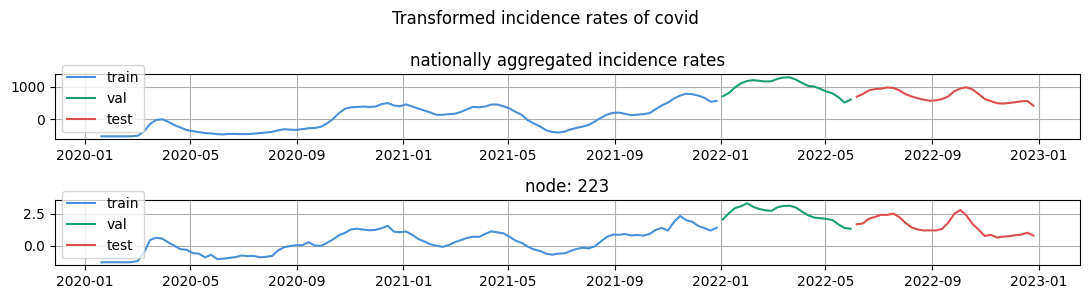

In [6]:
token_munich     = 223
token_jena       = 391
token_oberhausen = 69
token_hannover   = 26

epidata = EpiDataLoader('covid', data_env, aggr_level= '03', min_date='2020-01-01',max_date='2023-01-01')
epidata.log_transform_target()
epidata.add_time_features()
epidata.normalize('2022-01-01','2022-06-01','zscore')
epidata.add_lagged_features(range(1,3))
epidata.preview([token_munich],status = 'split', y ='cases')

In [8]:
from src.dataloading.gnndataloader import GNNDataLoader

n_periods = 1
n_epochs  = 100
horizon   = 1
lags      = range(1,4)


if 'population_size' in epidata.feature_columns:
    epidata.feature_columns.remove('population_size')

covid_loader1 = GNNDataLoader(epidata).retrieve_graph('identity_graph').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
covid_loader2 = GNNDataLoader(epidata).retrieve_graph('gravity_model_self0_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
covid_loader3 = GNNDataLoader(epidata).retrieve_graph('gravity_model_top8_self0_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
covid_loader4 = GNNDataLoader(epidata).retrieve_graph('boolean_neighbors_self0').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataloader Snapshot: Data(x=[411, 4, 1], edge_index=[2, 411], y=[411, 1], edge_weight=[411])
Epoch 1 train loss: 0.9305, val loss: 6.1615 ✓ (new best)
Epoch 2 train loss: 0.8870, val loss: 5.8722 ✓ (new best)
Epoch 3 train loss: 0.8450, val loss: 5.5943 ✓ (new best)
Epoch 4 train loss: 0.8042, val loss: 5.3237 ✓ (new best)
Epoch 5 train loss: 0.7646, val loss: 5.0550 ✓ (new best)
Epoch 6 train loss: 0.7258, val loss: 4.7878 ✓ (new best)
Epoch 7 train loss: 0.6881, val loss: 4.5243 ✓ (new best)
Epoch 8 train loss: 0.6516, val loss: 4.2658 ✓ (new best)
Epoch 9 train loss: 0.6163, val loss: 4.0133 ✓ (new best)
Epoch 10 train loss: 0.5859, val loss: 3.8286 ✓ (new best)
Epoch 11 train loss: 0.5611, val loss: 3.6469 ✓ (new best)
Epoch 12 train loss: 0.5371, val loss: 3.4682 ✓ (new best)
Epoch 13 train loss: 0.5140, val loss: 3.2934 ✓ (new best)
Epoch 14 train loss: 0.4920, val loss: 3.1229 ✓ (new best)
Epoch 15 train loss: 0.4709, val loss: 2.9571 ✓ (new best)
Epoch 16 train loss: 0.4510, va

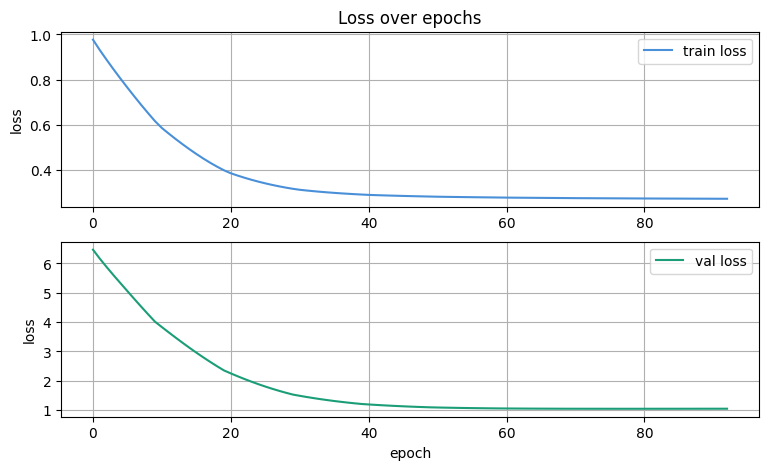

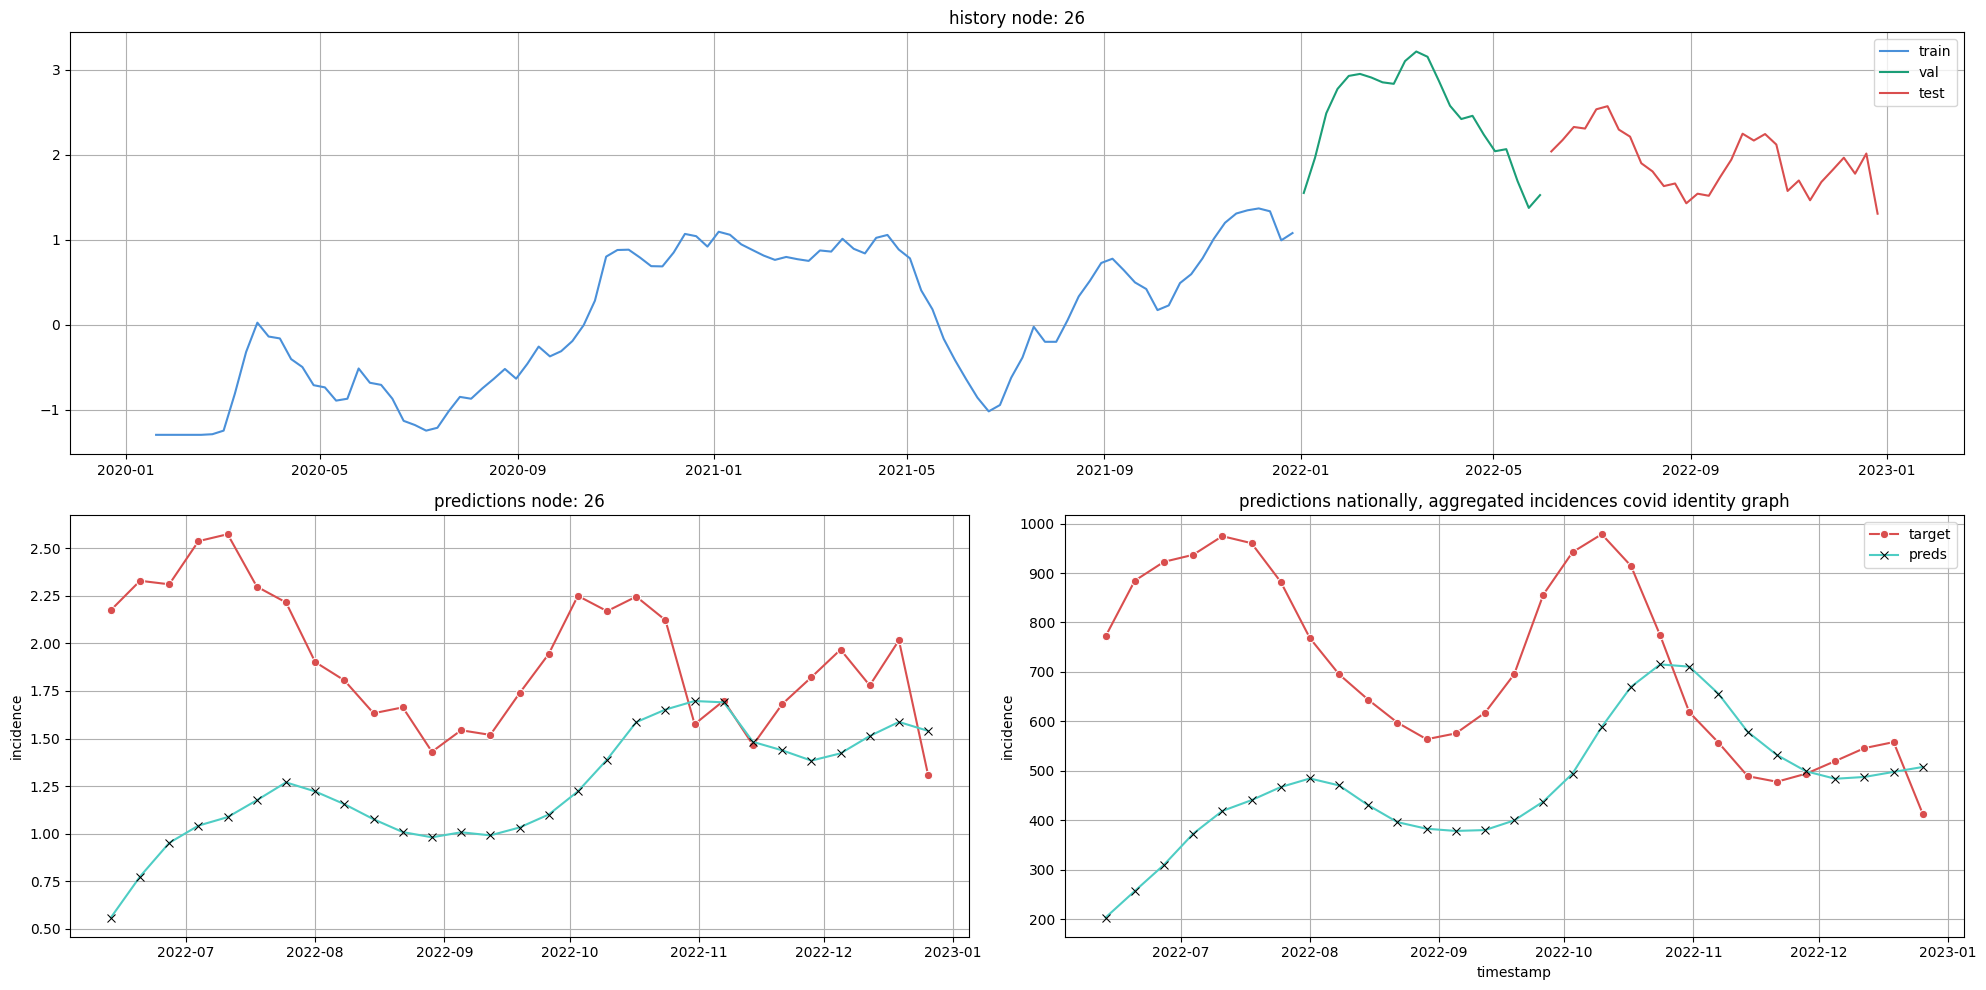

In [10]:
from src.models.spatial_gcn import SpatialGCNModel

n_epochs = 200

ml = SpatialGCNModel(name = f'covid identity graph', dataloader=covid_loader1)
ml.set_model_hparams()
ml.set_global_hparams(lr = 0.00001, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.75}, min_delta = 0.00001, loss = 'mse')
ml.train()
ml.forecast()
ml.show_forecasts(26)

Dataloader Snapshot: Data(x=[411, 4, 1], edge_index=[2, 4255], y=[411, 1], edge_weight=[4255])
Epoch 1 train loss: 0.8899, val loss: 5.1515 ✓ (new best)
Epoch 2 train loss: 0.8458, val loss: 4.8755 ✓ (new best)
Epoch 3 train loss: 0.8034, val loss: 4.6115 ✓ (new best)
Epoch 4 train loss: 0.7625, val loss: 4.3562 ✓ (new best)
Epoch 5 train loss: 0.7228, val loss: 4.1064 ✓ (new best)
Epoch 6 train loss: 0.6842, val loss: 3.8595 ✓ (new best)
Epoch 7 train loss: 0.6467, val loss: 3.6183 ✓ (new best)
Epoch 8 train loss: 0.6104, val loss: 3.3840 ✓ (new best)
Epoch 9 train loss: 0.5754, val loss: 3.1571 ✓ (new best)
Epoch 10 train loss: 0.5452, val loss: 2.9918 ✓ (new best)
Epoch 11 train loss: 0.5210, val loss: 2.8311 ✓ (new best)
Epoch 12 train loss: 0.4978, val loss: 2.6751 ✓ (new best)
Epoch 13 train loss: 0.4756, val loss: 2.5239 ✓ (new best)
Epoch 14 train loss: 0.4546, val loss: 2.3777 ✓ (new best)
Epoch 15 train loss: 0.4347, val loss: 2.2373 ✓ (new best)
Epoch 16 train loss: 0.4160, 

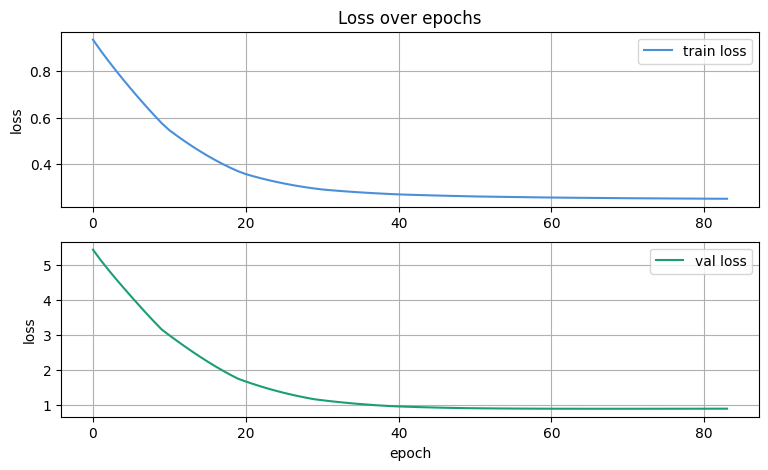

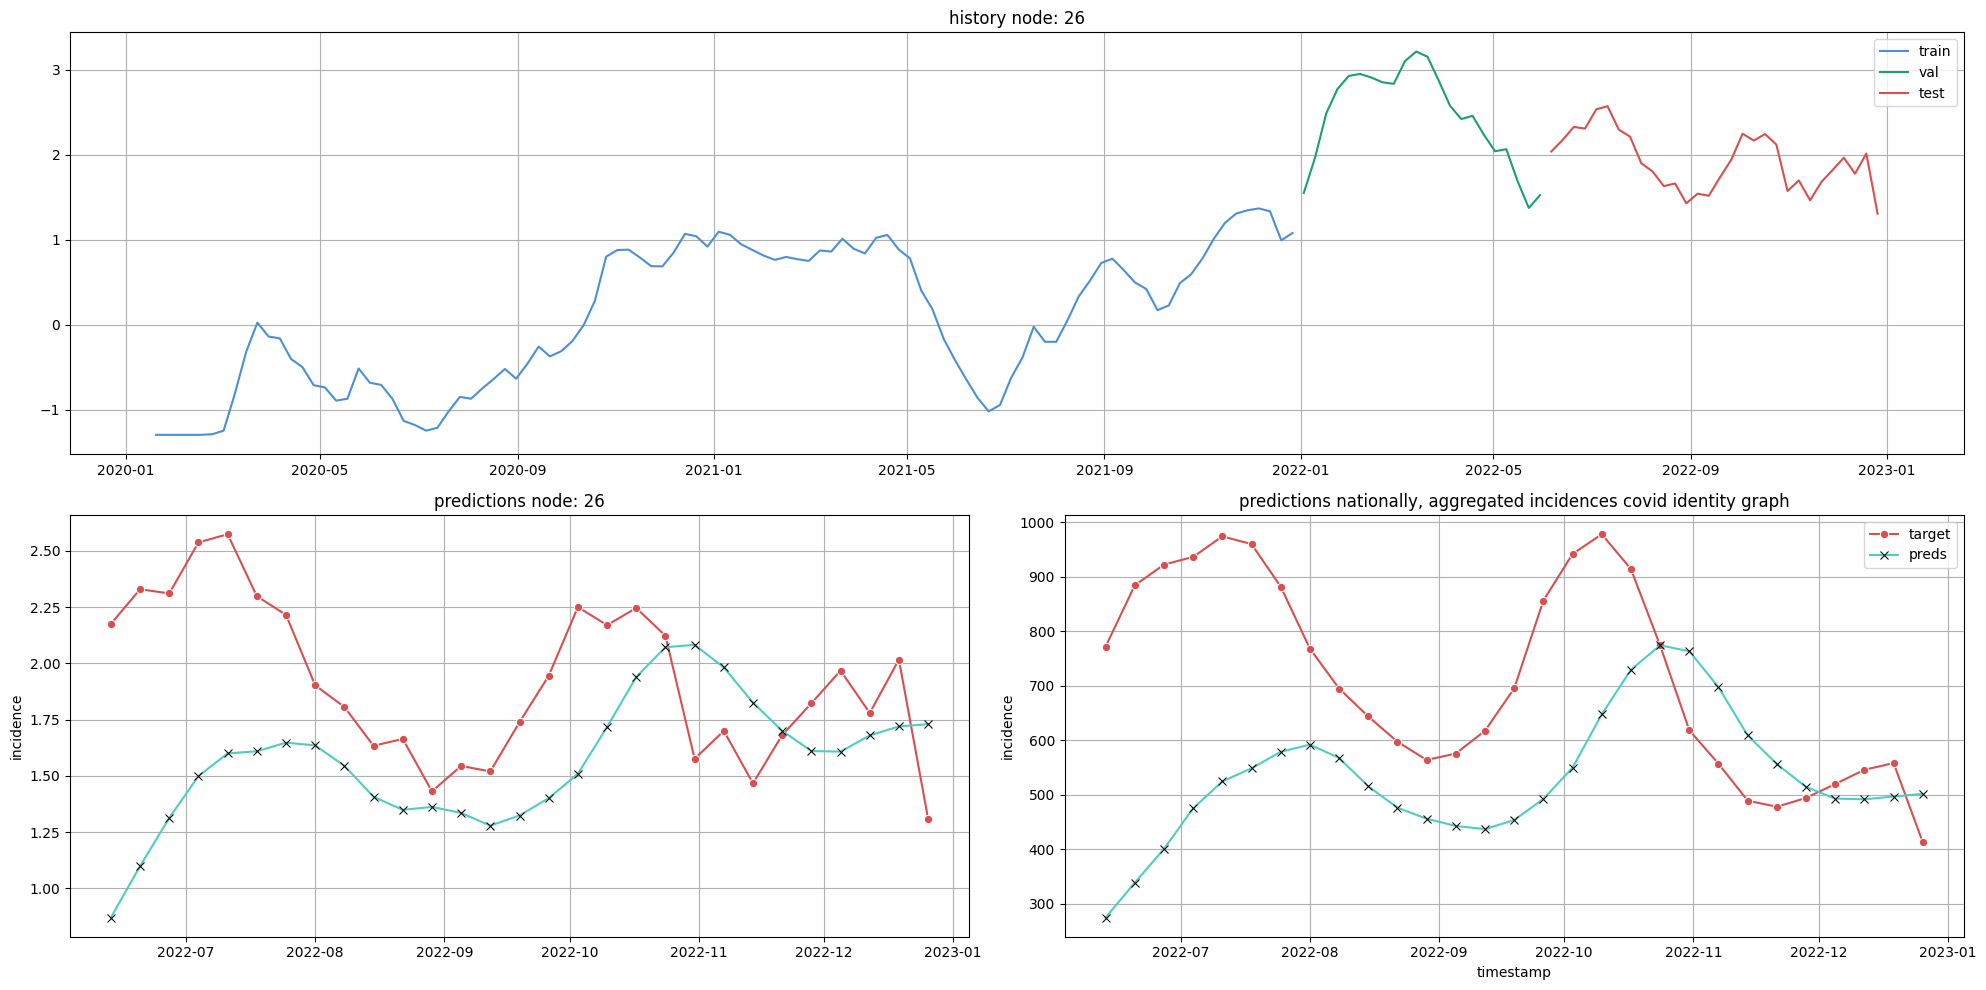

In [11]:
ml = SpatialGCNModel(name = f'covid identity graph', dataloader=covid_loader2)
ml.set_model_hparams()
ml.set_global_hparams(lr = 0.00001, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.75}, min_delta = 0.00001, loss = 'mse')
ml.train()
ml.forecast()
ml.show_forecasts(26)

Dataloader Snapshot: Data(x=[411, 4, 1], edge_index=[2, 2529], y=[411, 1], edge_weight=[2529])
Epoch 1 train loss: 0.9300, val loss: 6.1886 ✓ (new best)
Epoch 2 train loss: 0.8871, val loss: 5.9336 ✓ (new best)
Epoch 3 train loss: 0.8452, val loss: 5.6855 ✓ (new best)
Epoch 4 train loss: 0.8041, val loss: 5.4406 ✓ (new best)
Epoch 5 train loss: 0.7639, val loss: 5.1979 ✓ (new best)
Epoch 6 train loss: 0.7249, val loss: 4.9579 ✓ (new best)
Epoch 7 train loss: 0.6868, val loss: 4.7193 ✓ (new best)
Epoch 8 train loss: 0.6498, val loss: 4.4812 ✓ (new best)
Epoch 9 train loss: 0.6140, val loss: 4.2425 ✓ (new best)
Epoch 10 train loss: 0.5833, val loss: 4.0626 ✓ (new best)
Epoch 11 train loss: 0.5585, val loss: 3.8840 ✓ (new best)
Epoch 12 train loss: 0.5347, val loss: 3.7080 ✓ (new best)
Epoch 13 train loss: 0.5119, val loss: 3.5348 ✓ (new best)
Epoch 14 train loss: 0.4902, val loss: 3.3647 ✓ (new best)
Epoch 15 train loss: 0.4696, val loss: 3.1978 ✓ (new best)
Epoch 16 train loss: 0.4500, 

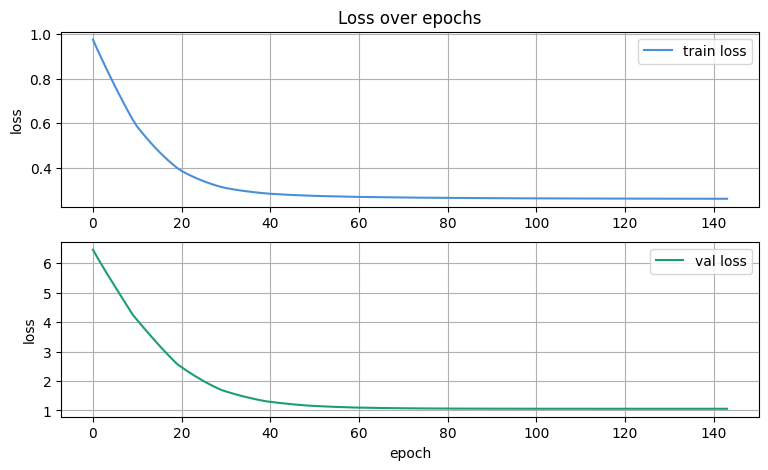

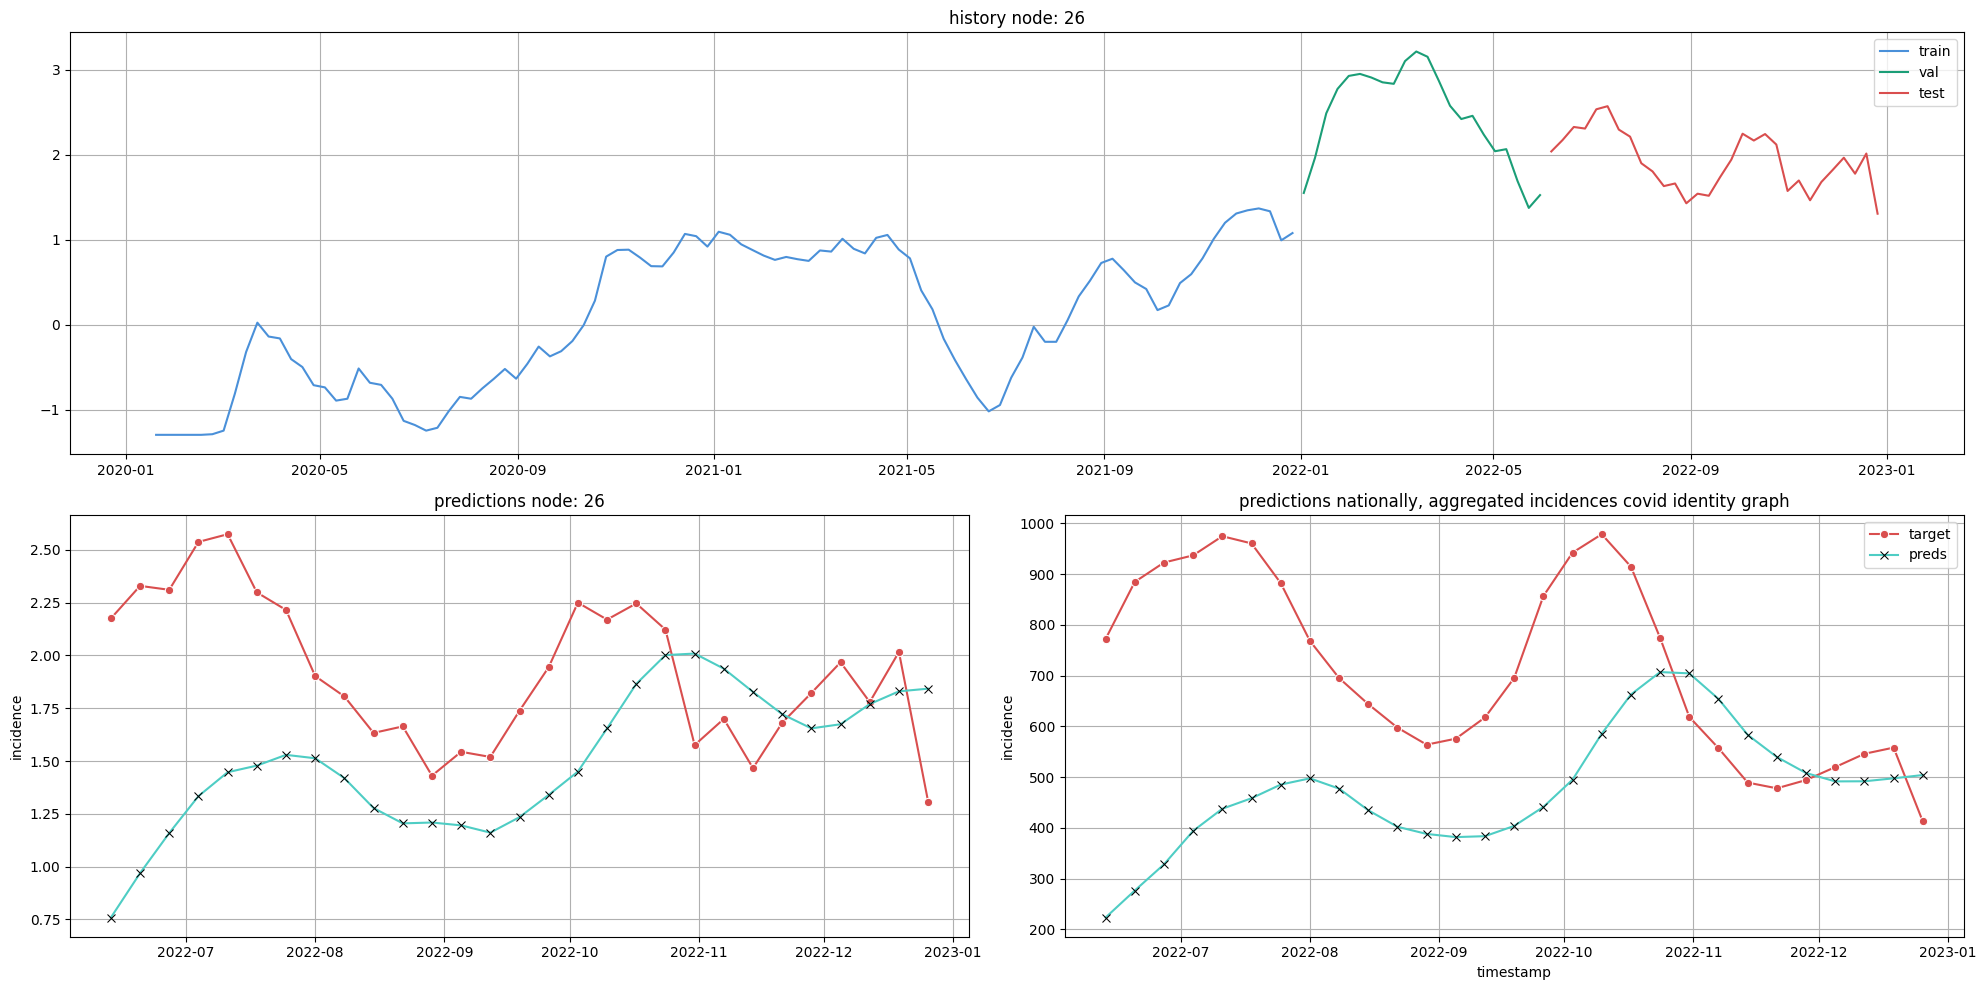

In [14]:
from src.models.spatial_gcn import SpatialGCNModel

n_epochs = 200

ml = SpatialGCNModel(name = f'covid identity graph', dataloader=covid_loader4)
ml.set_model_hparams()
ml.set_global_hparams(lr = 0.00001, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.75}, min_delta = 0.00001, loss = 'mse')
ml.train()
ml.forecast()
ml.show_forecasts(26)